# Production-Grade Log Anomaly Detection on HDFS Logs

This notebook upgrades the earlier prototype into a reproducible, documented, end-to-end anomaly detection workflow for structured HDFS logs.

## Objectives
- frame log anomaly detection as an operations and reliability problem
- validate and prepare structured HDFS logs
- engineer stronger production-style features
- score anomalies with **Isolation Forest** and compare with **DBSCAN**
- evaluate against labels **if available**
- generate ranked outputs, plots, and reusable artifacts
- document deployment, thresholding, and monitoring considerations

## 1. Problem framing

Modern systems emit large volumes of logs, and manually inspecting them is not scalable. An anomaly detector helps prioritize rare, surprising, or suspicious events that may indicate failures, misconfigurations, or security incidents.

In this notebook we treat anomaly detection as a **ranking problem** rather than a pure yes/no classifier:
- high anomaly scores should push the most unusual log lines to the top
- thresholds should be configurable based on alerting tolerance
- output should be interpretable enough for operators to review

We use a hybrid workflow:
- **Unsupervised core**: Isolation Forest learns normal vs unusual behavior without requiring labels
- **Optional labeled evaluation**: if HDFS anomaly labels are available, we evaluate precision, recall, F1, PR-AUC, and ROC-AUC

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import JSON, Markdown, display

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOTTING_AVAILABLE = True
except ModuleNotFoundError:
    plt = None
    sns = None
    PLOTTING_AVAILABLE = False
    print("Plotting libraries are not installed in this environment. Core pipeline features still work; plotting cells will need matplotlib and seaborn.")

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

from log_anomaly_config import get_default_config
from log_anomaly_pipeline import (
    add_dbscan_comparison,
    attach_labels,
    build_pca_frame,
    build_preprocessor,
    combine_model_features,
    engineer_features,
    evaluate_predictions,
    load_logs,
    load_optional_labels,
    save_artifacts,
    score_anomalies,
)
from log_anomaly_utils import (
    plot_pca_projection,
    plot_score_distribution,
    plot_sequence_anomalies,
    plot_template_anomalies,
    set_plot_style,
)

if PLOTTING_AVAILABLE:
    set_plot_style()

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

config = get_default_config(auto_download_labels=True)
print("Notebook directory:", NOTEBOOK_DIR)
print("Artifacts directory:", config.artifacts_dir)
print("Structured logs path:", config.structured_logs_path)
print("Labels path:", config.labels_path)

Notebook directory: c:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection
Artifacts directory: C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts
Structured logs path: C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\data\HDFS_2k.log_structured.csv
Labels path: C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\data\anomaly_label.csv


## 2. Dataset and schema assumptions

We use the **LogHub HDFS structured logs** sample. The structured CSV contains fields such as:
- `LineId`
- `Date`, `Time`
- `Pid`, `Level`, `Component`
- `Content`
- `EventId`, `EventTemplate`

The local structured log file is required for the notebook to run. The pipeline can also try to download an `anomaly_label.csv` file for optional hybrid evaluation. If labels are unavailable, the workflow still runs end to end in unsupervised mode.

Key production assumptions:
- schema should match expected columns
- log content is text that can be featurized
- `BlockId` can be extracted from HDFS content when present
- anomaly ranking is more useful operationally than only a binary flag

In [2]:
logs_df = load_logs(config)
labels_df = load_optional_labels(config)
logs_df = attach_labels(logs_df, labels_df)

print(f"Loaded {len(logs_df):,} log rows")
print(f"Columns: {logs_df.columns.tolist()}")
print(f"Rows with ground-truth labels available: {int(logs_df['HasGroundTruth'].sum()):,}")

display(logs_df.head())

Loaded 2,000 log rows
Columns: ['LineId', 'Date', 'Time', 'Pid', 'Level', 'Component', 'Content', 'EventId', 'EventTemplate', 'SequenceID', 'BlockId', 'HasBlockId', 'ContentLength', 'TokenCount', 'Label', 'HasGroundTruth']
Rows with ground-truth labels available: 0


,LineId,Date,Time,Pid,Level,Component,Content,EventId,EventTemplate,SequenceID,BlockId,HasBlockId,ContentLength,TokenCount,Label,HasGroundTruth
0,1,81109,203615,148,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_38865049064139660 terminating,E10,PacketResponder <*> for block blk_<*> terminating,0,blk_38865049064139660,1,61,6,Unknown,0
1,2,81109,203807,222,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-6952295868487656571 terminating,E10,PacketResponder <*> for block blk_<*> terminating,1,blk_-6952295868487656571,1,64,6,Unknown,0
2,3,81109,204005,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 671...,E6,BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>,2,blk_7128370237687728475,1,121,11,Unknown,0
3,4,81109,204015,308,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_8229193803249955061 terminating,E10,PacketResponder <*> for block blk_<*> terminating,3,blk_8229193803249955061,1,63,6,Unknown,0
4,5,81109,204106,329,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-6670958622368987959 terminating,E10,PacketResponder <*> for block blk_<*> terminating,4,blk_-6670958622368987959,1,64,6,Unknown,0


## 3. Exploratory data analysis

Before modeling, we check the basic shape of the data, missingness, and dominant templates/components. In production, this step maps closely to **schema validation** and **data quality monitoring**.

We especially care about:
- whether some templates dominate the stream
- whether components are imbalanced
- whether fields like `Content`, `EventTemplate`, or `Level` are missing
- whether anomaly labels exist for any subset of rows

,missing_count


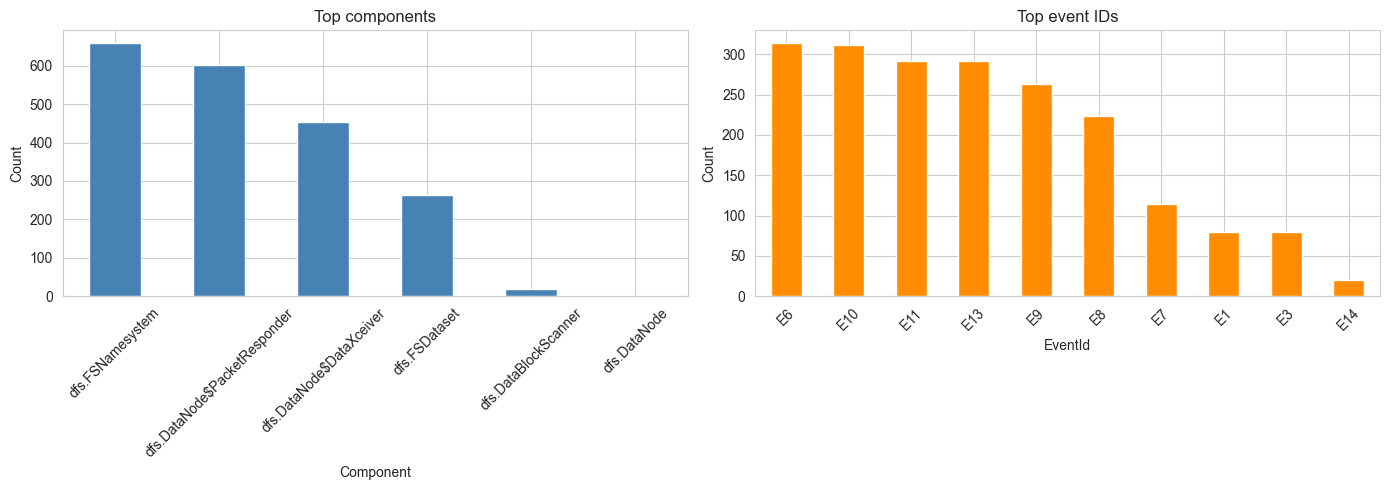

No local or downloaded anomaly labels were attached. Evaluation will stay in unsupervised mode.


In [3]:
missing_summary = logs_df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
display(missing_summary[missing_summary["missing_count"] > 0].head(15))

if PLOTTING_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    logs_df["Component"].value_counts().head(10).plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title("Top components")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    logs_df["EventId"].value_counts().head(10).plot(kind="bar", ax=axes[1], color="darkorange")
    axes[1].set_title("Top event IDs")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping EDA plots because matplotlib/seaborn are unavailable in this environment.")

if (logs_df["HasGroundTruth"] == 1).any():
    display(logs_df["Label"].value_counts(dropna=False).to_frame("count"))
else:
    print("No local or downloaded anomaly labels were attached. Evaluation will stay in unsupervised mode.")

## 4. Feature engineering

The original prototype mainly used row order, template IDs, and a small TF-IDF projection. Here we use a richer feature set more aligned with production practice:
- `SequenceID` to preserve stream order
- content statistics such as length and token count
- extracted `BlockId` and block frequency
- template/component/level frequency signals
- rare-template flag
- previous-row continuity features
- rolling-window template diversity
- structured categorical features plus TF-IDF text features

This gives the detector both **semantic** and **behavioral** context.

In [4]:
feature_df = engineer_features(logs_df)
preprocessor, categorical_cols, numeric_cols = build_preprocessor(feature_df, config)
combined_matrix, vectorizer = combine_model_features(feature_df, preprocessor, config)

print("Categorical model columns:", categorical_cols)
print("Numeric model columns:", numeric_cols)
print("Combined feature matrix shape:", combined_matrix.shape)
print("Top TF-IDF vocabulary sample:", vectorizer.get_feature_names_out()[:15].tolist())

display(
    feature_df[
        [
            "SequenceID",
            "Component",
            "EventId",
            "EventTemplate",
            "ContentLength",
            "TokenCount",
            "TemplateFrequency",
            "BlockFrequency",
            "IsRareTemplate",
            "WindowTemplateUniques",
        ]
    ].head()
)

Categorical model columns: ['EventTemplate', 'EventId', 'Component', 'Level', 'BlockId']
Numeric model columns: ['SequenceID', 'EventTemplateCode', 'Pid', 'ContentLength', 'TokenCount', 'TemplateFrequency', 'ComponentFrequency', 'LevelFrequency', 'BlockFrequency', 'HasBlockId', 'IsRareTemplate', 'PrevSameTemplate', 'PrevSameComponent', 'WindowTemplateUniques', 'SequenceDelta']
Combined feature matrix shape: (2000, 2125)
Top TF-IDF vocabulary sample: ['10', '10 250', '10 251', '203', '214', '250', '251', '251 214', '251 39', '251 42', '30', '39', '42', '50010', '50010 added']


,SequenceID,Component,EventId,EventTemplate,ContentLength,TokenCount,TemplateFrequency,BlockFrequency,IsRareTemplate,WindowTemplateUniques
0,0,dfs.DataNode$PacketResponder,E10,PacketResponder <*> for block blk_<*> terminating,61,6,311,1,0,1.0
1,1,dfs.DataNode$PacketResponder,E10,PacketResponder <*> for block blk_<*> terminating,64,6,311,1,0,1.0
2,2,dfs.FSNamesystem,E6,BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>,121,11,314,1,0,2.0
3,3,dfs.DataNode$PacketResponder,E10,PacketResponder <*> for block blk_<*> terminating,63,6,311,1,0,2.0
4,4,dfs.DataNode$PacketResponder,E10,PacketResponder <*> for block blk_<*> terminating,64,6,311,1,0,2.0


## 5. Model training and anomaly scoring

We keep **Isolation Forest** as the primary model because it is practical for unsupervised anomaly ranking on mixed high-dimensional features.

We also compute a **DBSCAN** comparison signal when enabled:
- Isolation Forest gives a continuous anomaly score and a configurable threshold
- DBSCAN provides a second view of outlier structure
- agreement/disagreement between detectors is useful during analysis

The threshold is chosen from the configured contamination rate, which makes it explicit and operationally tunable.

In [5]:
scored_df, model, raw_scores = score_anomalies(feature_df, combined_matrix, config)
scored_df = add_dbscan_comparison(scored_df, combined_matrix, config)
metrics = evaluate_predictions(scored_df)
pca_df = build_pca_frame(scored_df, combined_matrix, config)
save_artifacts(scored_df, preprocessor, model, vectorizer, metrics, config)

print("Predicted anomalies:", int(scored_df["is_anomaly"].sum()))
print("Predicted anomaly rate:", round(float(scored_df["is_anomaly"].mean()), 4))
print("Detector agreement rate:", round(float(scored_df["detector_agreement"].mean()), 4))
print("Isolation Forest threshold:", round(float(scored_df["anomaly_threshold"].iloc[0]), 4))

Predicted anomalies: 100
Predicted anomaly rate: 0.05
Detector agreement rate: 0.05
Isolation Forest threshold: 0.3596


## 6. Ranked anomalies and thresholding

In production, investigators usually care about the **top suspicious records** first. A ranked list is more actionable than a flat binary label.

Below we inspect the highest-scoring anomalies and look at the key fields needed for triage.

In [6]:
top_anomalies = scored_df.nlargest(config.top_n_anomalies, "anomaly_score")
triage_columns = [
    col
    for col in [
        "rank",
        "anomaly_score",
        "dbscan_is_anomaly",
        "SequenceID",
        "Component",
        "Level",
        "EventId",
        "EventTemplate",
        "BlockId",
        "Label",
        "Content",
    ]
    if col in top_anomalies.columns
]

display(top_anomalies[triage_columns].head(15))

,rank,anomaly_score,dbscan_is_anomaly,SequenceID,Component,Level,EventId,EventTemplate,BlockId,Label,Content
295,1,0.379091,1,295,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_-8023826090828946372,Unknown,10.251.42.191:50010:Got exception while serving blk_-8023826090828946372 to /10.251.214.130:
91,2,0.377004,1,91,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_5126469776250053435,Unknown,10.250.10.144:50010:Got exception while serving blk_5126469776250053435 to /10.250.11.100:
84,3,0.373188,1,84,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_-3140754468249228022,Unknown,10.250.9.207:50010:Got exception while serving blk_-3140754468249228022 to /10.250.9.207:
95,4,0.373054,1,95,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_5905933788014151041,Unknown,10.251.214.112:50010:Got exception while serving blk_5905933788014151041 to /10.251.214.112:
798,5,0.372682,1,798,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_9095955277706686312,Unknown,10.250.10.223:50010:Got exception while serving blk_9095955277706686312 to /10.250.5.161:
790,6,0.372039,1,790,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_-7125370327234065733,Unknown,10.250.11.53:50010:Got exception while serving blk_-7125370327234065733 to /10.250.15.240:
682,7,0.371958,1,682,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_-3056652732896088330,Unknown,10.251.42.246:50010:Got exception while serving blk_-3056652732896088330 to /10.251.27.63:
100,8,0.371635,1,100,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_7517964792804498202,Unknown,10.251.73.188:50010:Got exception while serving blk_7517964792804498202 to /10.250.6.191:
683,9,0.371500,1,683,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_73389299186801686,Unknown,10.250.13.188:50010:Got exception while serving blk_73389299186801686 to /10.251.123.33:
786,10,0.371476,1,786,dfs.DataNode$DataXceiver,WARN,E3,<*>:<*>:Got exception while serving blk_<*> to /<*>:,blk_-5340885607150360719,Unknown,10.251.30.101:50010:Got exception while serving blk_-5340885607150360719 to /10.251.30.101:


## 7. Hybrid evaluation

If labels are available, we compute standard metrics against ground truth. If not, the workflow remains fully usable and the metrics dictionary explicitly reports unsupervised-only mode.

This dual behavior is important in production because many real log datasets have weak, delayed, or partial labels.

In [7]:
display(JSON(metrics))

important_metric_keys = [
    key
    for key in [
        "evaluation_mode",
        "row_count",
        "predicted_anomalies",
        "predicted_anomaly_rate",
        "detector_agreement_rate",
        "precision",
        "recall",
        "f1",
        "average_precision",
        "roc_auc",
    ]
    if key in metrics
]

display(pd.DataFrame([{key: metrics[key] for key in important_metric_keys}]))

<IPython.core.display.JSON object>

,evaluation_mode,row_count,predicted_anomalies,predicted_anomaly_rate,detector_agreement_rate
0,unsupervised_only,2000,100,0.05,0.05


## 8. Explainability and operational interpretation

We do not treat anomaly detection as a black box. Operators should be able to answer:
- where anomalies sit in a reduced 2D projection
- whether score distributions look stable
- which templates dominate anomalous rows
- whether suspicious events cluster in certain regions of the stream

These outputs support human review, threshold tuning, and dashboarding.

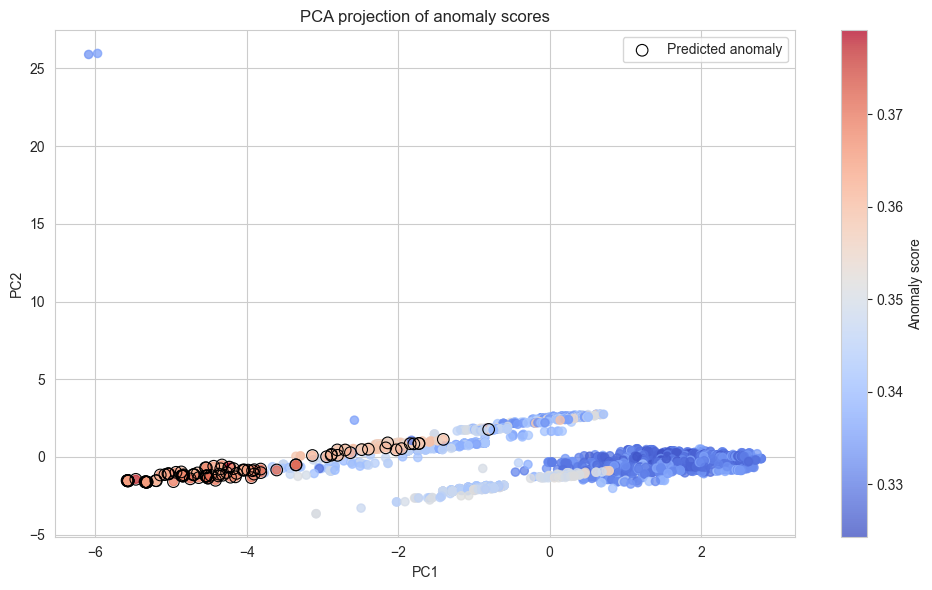

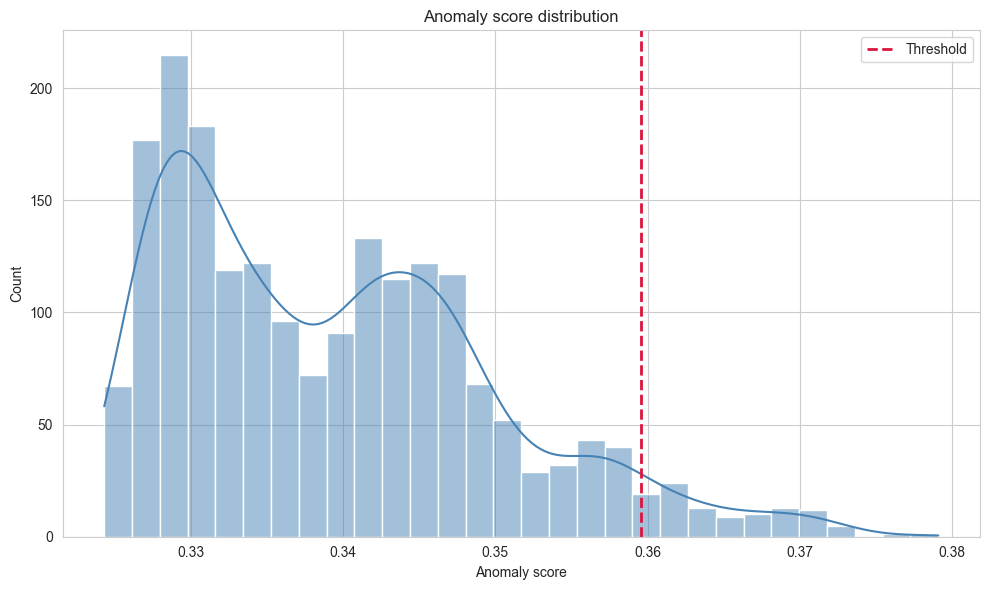

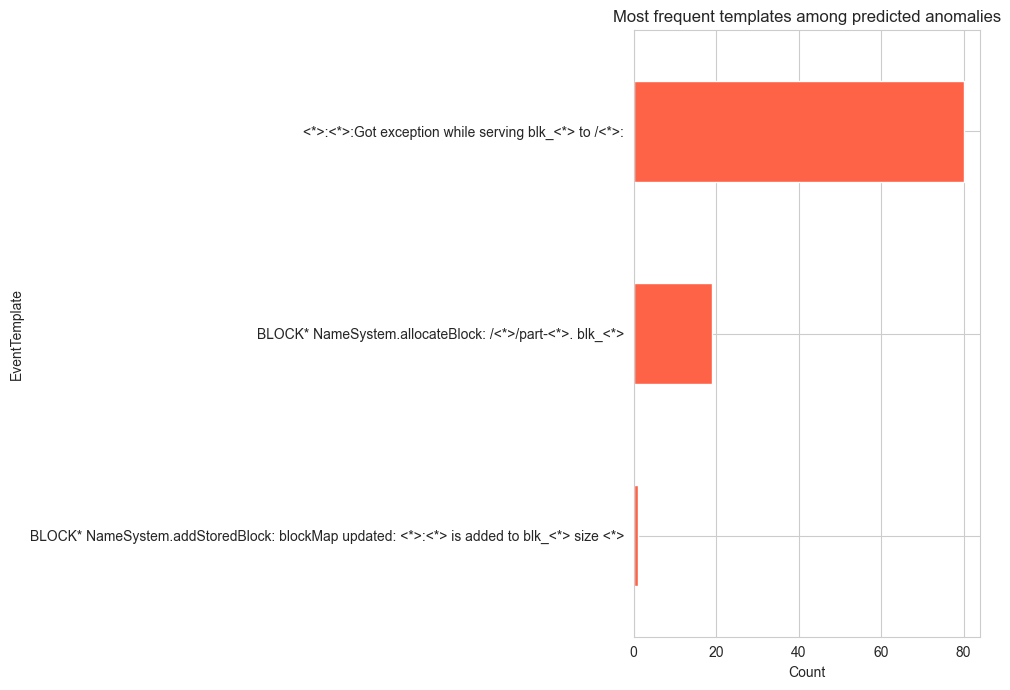

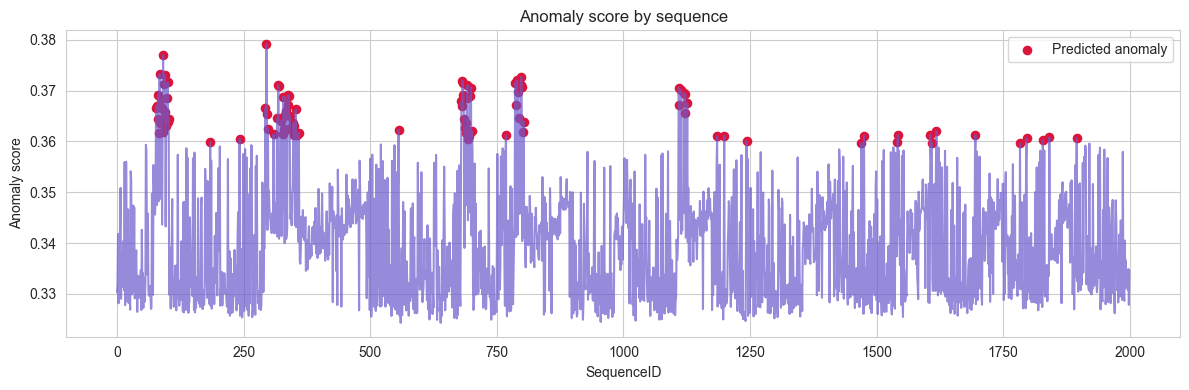

,anomaly_count,anomaly_rate,row_count
Component,,,
dfs.DataNode$DataXceiver,80,0.176211,454
dfs.FSNamesystem,20,0.030349,659
dfs.DataBlockScanner,0,0.000000,20
dfs.DataNode,0,0.000000,1
dfs.DataNode$PacketResponder,0,0.000000,603
dfs.FSDataset,0,0.000000,263


,anomaly_count,anomaly_rate,row_count
EventTemplate,,,
<*>:<*>:Got exception while serving blk_<*> to /<*>:,80,1.000000,80
BLOCK* NameSystem.allocateBlock: /<*>/part-<*>. blk_<*>,19,0.165217,115
BLOCK* NameSystem.addStoredBlock: blockMap updated: <*>:<*> is added to blk_<*> size <*>,1,0.003185,314
<*>:<*> Served block blk_<*> to /<*>,0,0.000000,80
<*>:<*> Starting thread to transfer block blk_<*> to <*>:<*>,0,0.000000,1
BLOCK* NameSystem.delete: blk_<*> is added to invalidSet of <*>:<*>,0,0.000000,224
BLOCK* ask <*>:<*> to delete blk_<*>,0,0.000000,5
BLOCK* ask <*>:<*> to replicate blk_<*> to datanode(s) <*>:<*>,0,0.000000,1
Deleting block blk_<*> file /<*>/blk_<*>,0,0.000000,263


In [8]:
if PLOTTING_AVAILABLE:
    plot_pca_projection(pca_df, config.pca_plot_path)
    plot_score_distribution(scored_df, config.score_plot_path)
    plot_template_anomalies(scored_df, config.template_plot_path)
    plot_sequence_anomalies(scored_df, config.sequence_plot_path)
else:
    print("Skipping plot generation because matplotlib/seaborn are unavailable in this environment.")

component_anomaly_summary = (
    scored_df.groupby("Component")["is_anomaly"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "anomaly_count", "mean": "anomaly_rate", "count": "row_count"})
    .sort_values(["anomaly_count", "anomaly_rate"], ascending=False)
)

template_anomaly_summary = (
    scored_df.groupby("EventTemplate")["is_anomaly"]
    .agg(["sum", "mean", "count"])
    .rename(columns={"sum": "anomaly_count", "mean": "anomaly_rate", "count": "row_count"})
    .sort_values(["anomaly_count", "anomaly_rate"], ascending=False)
)

display(component_anomaly_summary.head(10))
display(template_anomaly_summary.head(10))

## 9. Artifacts and productionization notes

The pipeline saves reusable artifacts to the configured artifacts directory:
- scored logs CSV
- top anomalies CSV
- metrics JSON
- serialized Isolation Forest model
- serialized preprocessing pipeline
- saved plot images

### How this becomes production-grade
- keep schema validation at ingestion time
- monitor score drift, template drift, and volume changes over time
- make contamination and alert thresholds configurable per service
- version preprocessing and model artifacts together
- review false positives with operators and tune features/thresholds
- prefer session/block/window aggregation for richer detection in real systems

### Limitations
- row-level anomaly detection can miss multi-line or session-level failure patterns
- weak or missing labels limit offline evaluation quality
- DBSCAN on dense transformed features is mainly a comparison aid here, not the primary production detector

In [9]:
artifact_summary = pd.DataFrame(
    {
        "artifact": [
            "scored_logs_csv",
            "top_anomalies_csv",
            "metrics_json",
            "pca_plot",
            "template_plot",
            "score_plot",
            "sequence_plot",
        ],
        "path": [
            str(config.scored_logs_path),
            str(config.top_anomalies_path),
            str(config.metrics_path),
            str(config.pca_plot_path),
            str(config.template_plot_path),
            str(config.score_plot_path),
            str(config.sequence_plot_path),
        ],
    }
)

display(artifact_summary)
print("Notebook completed successfully.")

,artifact,path
0,scored_logs_csv,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\scored_logs.csv
1,top_anomalies_csv,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\top_anomalies.csv
2,metrics_json,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\metrics.json
3,pca_plot,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\anomaly_pca.png
4,template_plot,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\template_anomalies.png
5,score_plot,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\score_distribution.png
6,sequence_plot,C:\Users\harsh\MLProjects\ML concepts\MLProjects\LogAnamolyDetection\artifacts\sequence_anomalies.png


Notebook completed successfully.
